# Phase 1 and Phase 2 Model Comparison


In [1]:
from pathlib import Path
import json

import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import xgboost as xgb
    XGB_IMPORT_ERROR = None
except Exception as exc:
    xgb = None
    XGB_IMPORT_ERROR = repr(exc)

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "top20_p8"
ROLLING_DATA_DIR = PROJECT_ROOT / "data" / "top20_rolling_p8"
LOG_DIR = PROJECT_ROOT / "logs"
MODEL_DIR = PROJECT_ROOT / "models"

LGBM_DIR = MODEL_DIR / "lgbm" / "top20_lgbm"
if not (LGBM_DIR / "best_lgbm.txt").exists():
    old_lgbm_dir = MODEL_DIR / "top20_lgbm"
    if (old_lgbm_dir / "best_lgbm.txt").exists():
        LGBM_DIR = old_lgbm_dir

WF_LGBM_DIR = MODEL_DIR / "lgbm" / "top20_walkforward"
XGB_DIR = MODEL_DIR / "xgboost" / "top20_xgb"
ROLLING_LGBM_DIR = MODEL_DIR / "lgbm" / "top20_rolling_lgbm"
ROLLING_XGB_DIR = MODEL_DIR / "xgboost" / "top20_rolling_xgb"

REPORT_PATHS = {
    "lgbm_top20": LOG_DIR / "train_top20_lgbm_report.json",
    "xgb_top20": LOG_DIR / "train_top20_xgb_report.json",
    "rolling_lgbm": LOG_DIR / "train_rolling_lgbm_report.json",
    "rolling_xgb": LOG_DIR / "train_rolling_xgb_report.json",
}

TARGET_COL = "responder_6"
WEIGHT_COL = "weight"
DATE_COL = "date_id"
CATEGORICAL_COLS = ["symbol_id", "feature_11"]
RANDOM_STATE = 42
SAMPLE_ROWS = 100_000

print({
    "xgboost_available": xgb is not None,
    "xgboost_import_error": XGB_IMPORT_ERROR,
    "base_data_exists": DATA_DIR.exists(),
    "rolling_data_exists": ROLLING_DATA_DIR.exists(),
    "lgbm_model_exists": (LGBM_DIR / "best_lgbm.txt").exists(),
    "xgb_model_exists": (XGB_DIR / "best_xgb.json").exists(),
    "rolling_lgbm_model_exists": (ROLLING_LGBM_DIR / "best_lgbm.txt").exists(),
    "rolling_xgb_model_exists": (ROLLING_XGB_DIR / "best_xgb.json").exists(),
    "walkforward_exists": (WF_LGBM_DIR / "walkforward_results.csv").exists(),
})


{'xgboost_available': False, 'xgboost_import_error': "ValueError('Mismatched version between the Python package and the native shared object.  Python package version: 3.3.0. Shared object version: 3.4.0. Shared object is loaded from: /opt/anaconda3/lib/python3.12/site-packages/xgboost/lib/libxgboost.dylib.\\nLikely cause:\\n  * XGBoost is first installed with anaconda then upgraded with pip. To fix it please remove one of the installations.')", 'base_data_exists': True, 'rolling_data_exists': False, 'lgbm_model_exists': True, 'xgb_model_exists': True, 'rolling_lgbm_model_exists': True, 'rolling_xgb_model_exists': True, 'walkforward_exists': True}


In [2]:
def weighted_r2(y_true, y_pred, weight):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    weight = np.asarray(weight, dtype=np.float64)
    numerator = np.sum(weight * np.square(y_true - y_pred))
    denominator = np.sum(weight * np.square(y_true))
    return np.nan if denominator == 0 else 1.0 - numerator / denominator


def weighted_rmse(y_true, y_pred, weight):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    weight = np.asarray(weight, dtype=np.float64)
    return np.sqrt(np.average(np.square(y_true - y_pred), weights=weight))


def load_split(name, data_dir=DATA_DIR):
    path = data_dir / f"{name}.parquet"
    if not path.exists():
        raise FileNotFoundError(path)
    df = pd.read_parquet(path)
    for col in CATEGORICAL_COLS:
        if col in df.columns:
            df[col] = df[col].astype("category")
    return df


def feature_cols(df):
    return [col for col in df.columns if col not in [DATE_COL, WEIGHT_COL, TARGET_COL, "_split"]]


def score_predictions(df, pred_col):
    return {
        "weighted_r2": weighted_r2(df[TARGET_COL], df[pred_col], df[WEIGHT_COL]),
        "weighted_rmse": weighted_rmse(df[TARGET_COL], df[pred_col], df[WEIGHT_COL]),
        "pred_mean": df[pred_col].mean(),
        "pred_std": df[pred_col].std(),
        "target_mean": df[TARGET_COL].mean(),
        "target_std": df[TARGET_COL].std(),
    }


def read_best_report(model_name, path):
    if not path.exists():
        return None
    report = json.loads(path.read_text())
    best = report.get("best", {})
    return {
        "model": model_name,
        "split": "valid",
        "valid_weighted_r2": best.get("valid_weighted_r2"),
        "best_iteration": best.get("best_iteration"),
        "best_config": best.get("name"),
        "report_path": str(path),
    }


In [3]:
train_df = load_split("train")
valid_df = load_split("valid")
test_df = load_split("test")
features = feature_cols(train_df)

rolling_splits = {}
rolling_features = []
if ROLLING_DATA_DIR.exists():
    rolling_splits = {
        "train": load_split("train", ROLLING_DATA_DIR),
        "valid": load_split("valid", ROLLING_DATA_DIR),
        "test": load_split("test", ROLLING_DATA_DIR),
    }
    rolling_features = feature_cols(rolling_splits["train"])

split_summary = pd.DataFrame([
    {"dataset": "top20", "split": "train", "rows": len(train_df), "date_min": train_df[DATE_COL].min(), "date_max": train_df[DATE_COL].max()},
    {"dataset": "top20", "split": "valid", "rows": len(valid_df), "date_min": valid_df[DATE_COL].min(), "date_max": valid_df[DATE_COL].max()},
    {"dataset": "top20", "split": "test", "rows": len(test_df), "date_min": test_df[DATE_COL].min(), "date_max": test_df[DATE_COL].max()},
])

if rolling_splits:
    rolling_summary = pd.DataFrame([
        {"dataset": "top20_rolling", "split": name, "rows": len(df), "date_min": df[DATE_COL].min(), "date_max": df[DATE_COL].max()}
        for name, df in rolling_splits.items()
    ])
    split_summary = pd.concat([split_summary, rolling_summary], ignore_index=True)

print({"top20_feature_count": len(features), "rolling_feature_count": len(rolling_features) if rolling_features else None})
split_summary


{'top20_feature_count': 20, 'rolling_feature_count': None}


,dataset,split,rows,date_min,date_max
0,top20,train,4162125,1360,1489
1,top20,valid,680149,1490,1509
2,top20,test,696017,1510,1529


In [4]:
def add_lgbm_predictions(model_name, split_name, df, feature_list, model_path):
    model = lgb.Booster(model_file=str(model_path))
    out = df.copy()
    out["model"] = model_name
    out["split"] = split_name
    out["prediction"] = model.predict(out[feature_list], num_iteration=model.best_iteration)
    out["residual"] = out[TARGET_COL] - out["prediction"]
    return out


def xgb_feature_frame(df, feature_list):
    X = df[feature_list].copy()
    for col in X.columns:
        if str(X[col].dtype) == "category":
            X[col] = X[col].cat.codes.astype("int16")
    return X


def add_xgb_predictions(model_name, split_name, df, feature_list, model_path):
    if xgb is None:
        return None
    model = xgb.Booster()
    model.load_model(str(model_path))
    X = xgb_feature_frame(df, feature_list)
    dm = xgb.DMatrix(X, feature_names=feature_list)
    out = df.copy()
    out["model"] = model_name
    out["split"] = split_name
    out["prediction"] = model.predict(dm)
    out["residual"] = out[TARGET_COL] - out["prediction"]
    return out


pred_frames = []
base_splits = {"train": train_df, "valid": valid_df, "test": test_df}

lgbm_path = LGBM_DIR / "best_lgbm.txt"
if lgbm_path.exists():
    pred_frames.extend([
        add_lgbm_predictions("lgbm_top20", name, df, features, lgbm_path)
        for name, df in base_splits.items()
    ])
else:
    print(f"missing: {lgbm_path}")

xgb_path = XGB_DIR / "best_xgb.json"
if xgb_path.exists() and xgb is not None:
    pred_frames.extend([
        add_xgb_predictions("xgb_top20", name, df, features, xgb_path)
        for name, df in base_splits.items()
    ])
elif xgb_path.exists() and xgb is None:
    print("XGBoost model exists, but xgboost is not installed in this environment.")
else:
    print(f"missing: {xgb_path}")

rolling_lgbm_path = ROLLING_LGBM_DIR / "best_lgbm.txt"
if rolling_splits and rolling_lgbm_path.exists():
    pred_frames.extend([
        add_lgbm_predictions("rolling_lgbm", name, df, rolling_features, rolling_lgbm_path)
        for name, df in rolling_splits.items()
    ])
elif rolling_lgbm_path.exists():
    print(f"rolling parquet not found locally, using report only for: {rolling_lgbm_path}")

rolling_xgb_path = ROLLING_XGB_DIR / "best_xgb.json"
if rolling_splits and rolling_xgb_path.exists() and xgb is not None:
    pred_frames.extend([
        add_xgb_predictions("rolling_xgb", name, df, rolling_features, rolling_xgb_path)
        for name, df in rolling_splits.items()
    ])
elif rolling_xgb_path.exists() and xgb is None:
    print("Rolling XGBoost model exists, but xgboost is not installed in this environment.")
elif rolling_xgb_path.exists():
    print(f"rolling parquet not found locally, using report only for: {rolling_xgb_path}")

pred_df = pd.concat([df for df in pred_frames if df is not None], ignore_index=True)
print(pred_df[["model", "split"]].value_counts().sort_index() if not pred_df.empty else "No local predictions computed.")


XGBoost model exists, but xgboost is not installed in this environment.
rolling parquet not found locally, using report only for: /Users/akshay/Desktop/js_kaggle/models/lgbm/top20_rolling_lgbm/best_lgbm.txt
Rolling XGBoost model exists, but xgboost is not installed in this environment.


model       split
lgbm_top20  test      696017
            train    4162125
            valid     680149
Name: count, dtype: int64


In [5]:
metrics = []
if not pred_df.empty:
    for (model_name, split_name), group in pred_df.groupby(["model", "split"]):
        row = {"model": model_name, "split": split_name, "rows": len(group), "source": "local_predictions"}
        row.update(score_predictions(group, "prediction"))
        metrics.append(row)

metrics_df = pd.DataFrame(metrics).sort_values(["model", "split"]) if metrics else pd.DataFrame()

report_rows = [read_best_report(model, path) for model, path in REPORT_PATHS.items()]
report_df = pd.DataFrame([row for row in report_rows if row is not None])

phase_score_df = report_df.rename(columns={"valid_weighted_r2": "weighted_r2"})[
    ["model", "split", "weighted_r2", "best_iteration", "best_config", "report_path"]
].sort_values("weighted_r2", ascending=False)

print("Validation scores from saved training reports")
display(phase_score_df)

if not metrics_df.empty:
    print("Scores recomputed from local parquet/model files")
    display(metrics_df)
else:
    print("No local prediction metrics computed.")


Validation scores from saved training reports


,model,split,weighted_r2,best_iteration,best_config,report_path
3,rolling_xgb,valid,0.005567,138,shallower,/Users/akshay/Desktop/js_kaggle/logs/train_rol...
1,xgb_top20,valid,0.005500,150,shallower,/Users/akshay/Desktop/js_kaggle/logs/train_top...
2,rolling_lgbm,valid,0.004498,51,more_regularized,/Users/akshay/Desktop/js_kaggle/logs/train_rol...
0,lgbm_top20,valid,0.004264,29,more_regularized,/Users/akshay/Desktop/js_kaggle/logs/train_top...


Scores recomputed from local parquet/model files


,model,split,rows,source,weighted_r2,weighted_rmse,pred_mean,pred_std,target_mean,target_std
0,lgbm_top20,test,696017,local_predictions,0.003757,0.583297,-0.002488,0.028044,-0.005696,0.611228
1,lgbm_top20,train,4162125,local_predictions,0.010943,0.800410,-0.004489,0.034679,-0.003797,0.842462
2,lgbm_top20,valid,680149,local_predictions,0.004264,0.599928,-0.005502,0.030588,-0.001343,0.634517


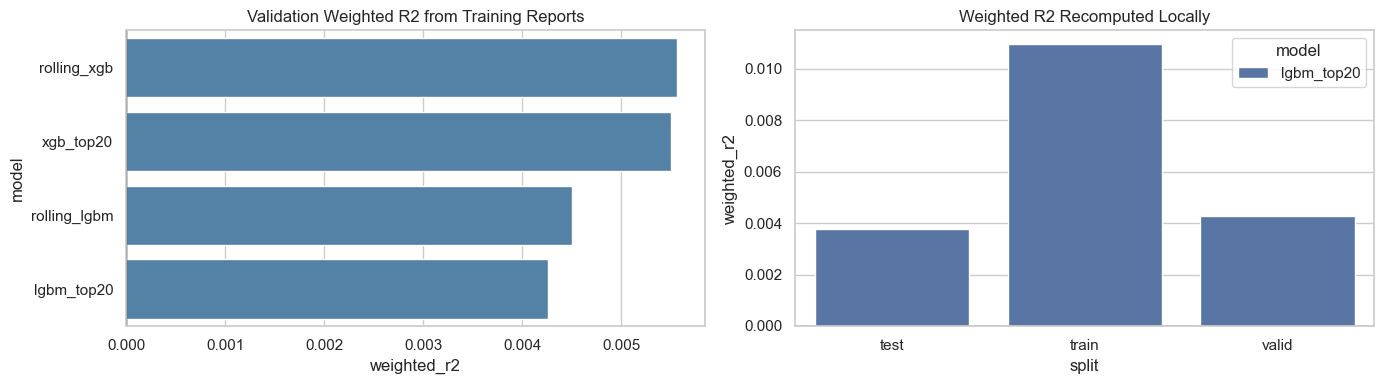

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(data=phase_score_df, x="weighted_r2", y="model", ax=axes[0], color="steelblue")
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Validation Weighted R2 from Training Reports")

if not metrics_df.empty:
    sns.barplot(data=metrics_df, x="split", y="weighted_r2", hue="model", ax=axes[1])
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].set_title("Weighted R2 Recomputed Locally")
else:
    axes[1].axis("off")

plt.tight_layout()


feature_set,family,top20,top20 + rolling,rolling_lift
0,LightGBM,0.004264,0.004498,0.000234
1,XGBoost,0.005500,0.005567,0.000067


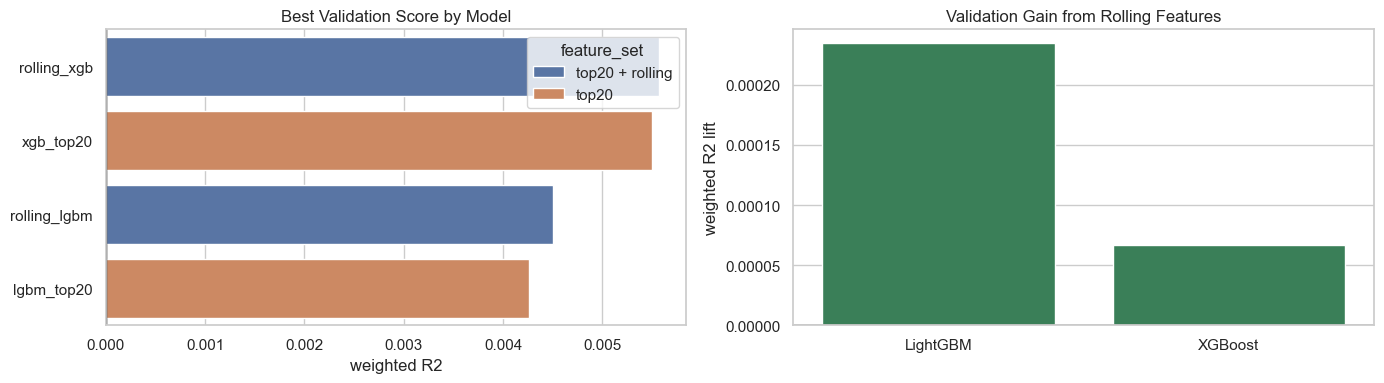

In [7]:
score_plot = phase_score_df.copy()
score_plot["family"] = np.select(
    [score_plot["model"].str.contains("xgb"), score_plot["model"].str.contains("lgbm")],
    ["XGBoost", "LightGBM"],
    default="Other",
)
score_plot["feature_set"] = np.where(score_plot["model"].str.contains("rolling"), "top20 + rolling", "top20")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(
    data=score_plot.sort_values("weighted_r2", ascending=False),
    x="weighted_r2",
    y="model",
    hue="feature_set",
    dodge=False,
    ax=axes[0],
)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Best Validation Score by Model")
axes[0].set_xlabel("weighted R2")
axes[0].set_ylabel("")

paired = score_plot.pivot_table(index="family", columns="feature_set", values="weighted_r2", aggfunc="max")
paired = paired.dropna(subset=["top20", "top20 + rolling"], how="any")
paired["rolling_lift"] = paired["top20 + rolling"] - paired["top20"]
lift_df = paired.reset_index()

sns.barplot(data=lift_df, x="family", y="rolling_lift", ax=axes[1], color="seagreen")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Validation Gain from Rolling Features")
axes[1].set_ylabel("weighted R2 lift")
axes[1].set_xlabel("")

plt.tight_layout()

display(lift_df)


,feature,model_count,best_rank
0,feature_04,4,1
1,symbol_id,4,1
2,feature_36,4,2
3,feature_06,4,3
4,time_id,4,3
5,feature_29,4,4
6,feature_58,4,4
7,feature_08,4,5
8,feature_31,4,5
9,feature_23,3,3


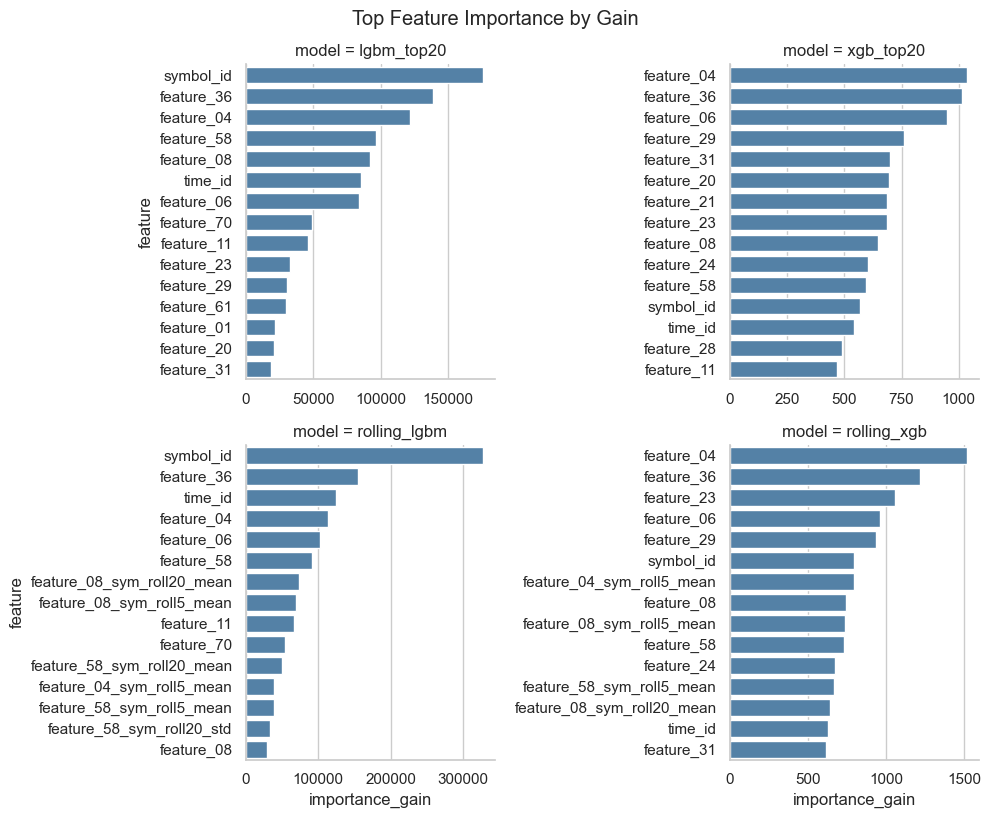

In [8]:
importance_paths = {
    "lgbm_top20": LGBM_DIR / "best_feature_importance.csv",
    "xgb_top20": XGB_DIR / "best_feature_importance.csv",
    "rolling_lgbm": ROLLING_LGBM_DIR / "best_feature_importance.csv",
    "rolling_xgb": ROLLING_XGB_DIR / "best_feature_importance.csv",
}

importance_frames = []
for model_name, path in importance_paths.items():
    if path.exists():
        imp = pd.read_csv(path)
        imp["model"] = model_name
        imp["rank"] = imp["importance_gain"].rank(method="first", ascending=False).astype(int)
        importance_frames.append(imp)

if importance_frames:
    importance_df = pd.concat(importance_frames, ignore_index=True)
    top_imp = importance_df[importance_df["rank"] <= 15].copy()

    g = sns.catplot(
        data=top_imp,
        x="importance_gain",
        y="feature",
        col="model",
        kind="bar",
        col_wrap=2,
        sharex=False,
        sharey=False,
        height=4,
        aspect=1.25,
        color="steelblue",
    )
    g.fig.suptitle("Top Feature Importance by Gain", y=1.02)

    top_features = (
        importance_df[importance_df["rank"] <= 20]
        .groupby("feature")
        .agg(model_count=("model", "nunique"), best_rank=("rank", "min"))
        .sort_values(["model_count", "best_rank"], ascending=[False, True])
        .reset_index()
    )
    display(top_features.head(25))
else:
    print("No feature importance files found yet.")


,model_family,name,valid_weighted_r2,best_iteration,elapsed_seconds,num_leaves,learning_rate,min_data_in_leaf,feature_fraction,bagging_fraction,lambda_l2,best_score_rmse,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda
11,rolling_xgb,shallower,0.005567,138,1.683548,NaN,0.03,NaN,NaN,NaN,NaN,0.599536,4.0,100.0,0.9,0.9,1.0
12,rolling_xgb,more_regularized,0.005553,126,1.801345,NaN,0.03,NaN,NaN,NaN,NaN,0.599540,5.0,200.0,0.8,0.8,5.0
13,rolling_xgb,baseline,0.005519,96,2.359936,NaN,0.03,NaN,NaN,NaN,NaN,0.599550,5.0,100.0,0.9,0.9,1.0
4,xgb_top20,shallower,0.005500,150,1.081066,NaN,0.03,NaN,NaN,NaN,NaN,0.599556,4.0,100.0,0.9,0.9,1.0
5,xgb_top20,slower_learning,0.005438,129,1.196043,NaN,0.02,NaN,NaN,NaN,NaN,0.599574,5.0,100.0,0.9,0.9,1.0
6,xgb_top20,baseline,0.005353,71,2.916334,NaN,0.03,NaN,NaN,NaN,NaN,0.599600,5.0,100.0,0.9,0.9,1.0
7,xgb_top20,more_regularized,0.005289,86,0.913476,NaN,0.03,NaN,NaN,NaN,NaN,0.599619,5.0,200.0,0.8,0.8,5.0
8,rolling_lgbm,more_regularized,0.004498,51,41.229172,64.0,0.03,1000.0,0.8,0.8,5.0,NaN,NaN,NaN,NaN,NaN,NaN
9,rolling_lgbm,smaller_leaves,0.004391,46,30.268595,31.0,0.03,500.0,0.9,0.9,1.0,NaN,NaN,NaN,NaN,NaN,NaN
0,lgbm_top20,more_regularized,0.004264,29,30.090332,64.0,0.03,1000.0,0.8,0.8,5.0,NaN,NaN,NaN,NaN,NaN,NaN


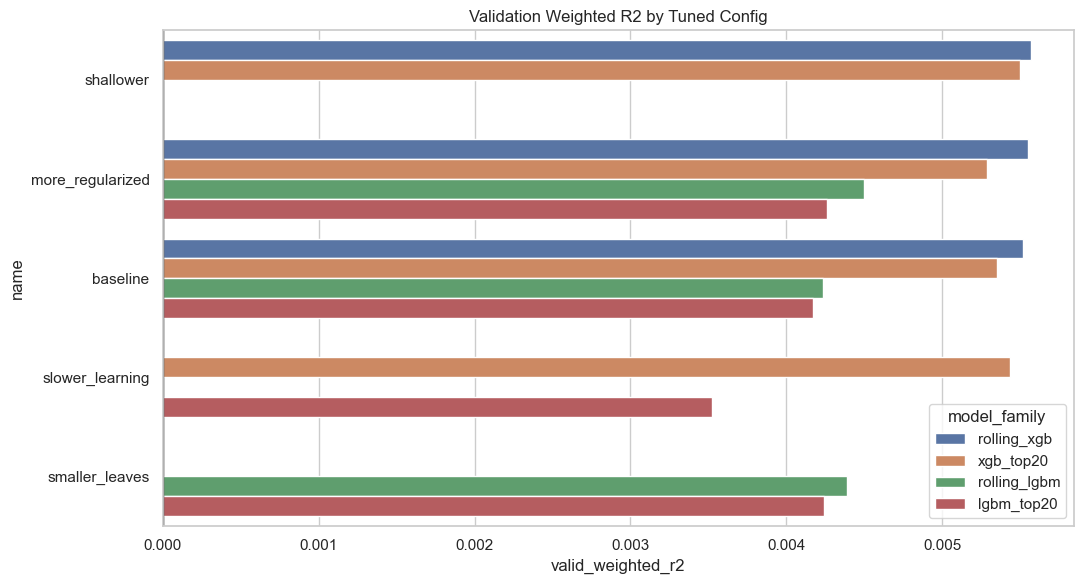

In [9]:
tuning_frames = []

for model_family, tuning_path in [
    ("lgbm_top20", LGBM_DIR / "tuning_results.csv"),
    ("xgb_top20", XGB_DIR / "tuning_results.csv"),
    ("rolling_lgbm", ROLLING_LGBM_DIR / "tuning_results.csv"),
    ("rolling_xgb", ROLLING_XGB_DIR / "tuning_results.csv"),
]:
    if tuning_path.exists():
        df = pd.read_csv(tuning_path)
        df.insert(0, "model_family", model_family)
        tuning_frames.append(df)

if tuning_frames:
    tuning_df = pd.concat(tuning_frames, ignore_index=True).sort_values("valid_weighted_r2", ascending=False)
    display(tuning_df)

    plt.figure(figsize=(11, 6))
    sns.barplot(data=tuning_df, x="valid_weighted_r2", y="name", hue="model_family")
    plt.axvline(0, color="black", linewidth=1)
    plt.title("Validation Weighted R2 by Tuned Config")
    plt.tight_layout()
else:
    print("No tuning result files found yet.")


,fold,valid_date_min,valid_date_max,train_rows,valid_rows,best_iteration,valid_weighted_r2,elapsed_seconds,model_path
0,1,1490,1494,4162125,160919,75,0.006254,47.246419,/users/s/a/sakshay/js_kaggle/models/lgbm/top20...
1,2,1495,1499,4323044,173383,33,0.003892,33.080611,/users/s/a/sakshay/js_kaggle/models/lgbm/top20...
2,3,1500,1504,4496427,170925,42,0.004225,36.075740,/users/s/a/sakshay/js_kaggle/models/lgbm/top20...
3,4,1505,1509,4667352,174922,132,0.009986,53.360893,/users/s/a/sakshay/js_kaggle/models/lgbm/top20...


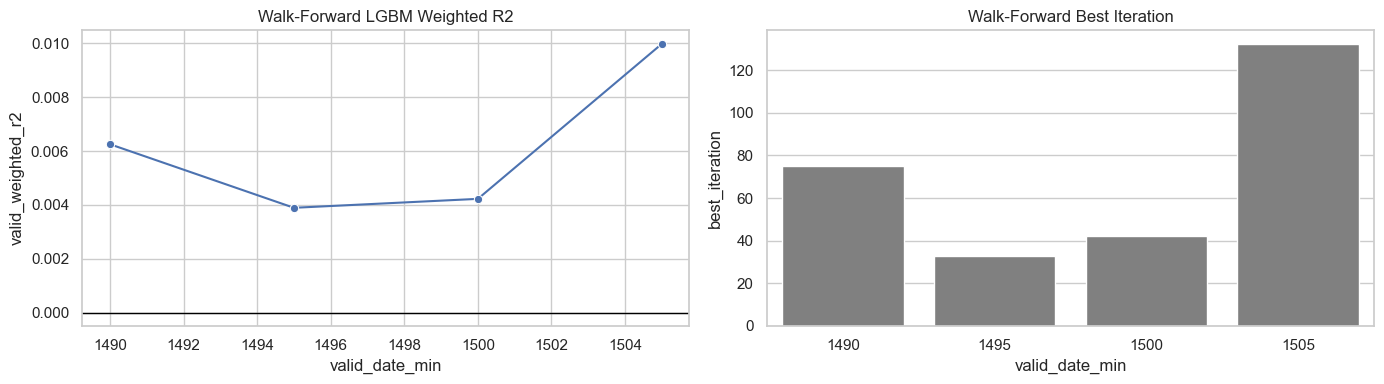

In [10]:
wf_path = WF_LGBM_DIR / "walkforward_results.csv"
if wf_path.exists():
    wf_df = pd.read_csv(wf_path)
    display(wf_df)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.lineplot(data=wf_df, x="valid_date_min", y="valid_weighted_r2", marker="o", ax=axes[0])
    axes[0].axhline(0, color="black", linewidth=1)
    axes[0].set_title("Walk-Forward LGBM Weighted R2")

    sns.barplot(data=wf_df, x="valid_date_min", y="best_iteration", ax=axes[1], color="gray")
    axes[1].set_title("Walk-Forward Best Iteration")
    plt.tight_layout()
else:
    print(f"missing: {wf_path}")

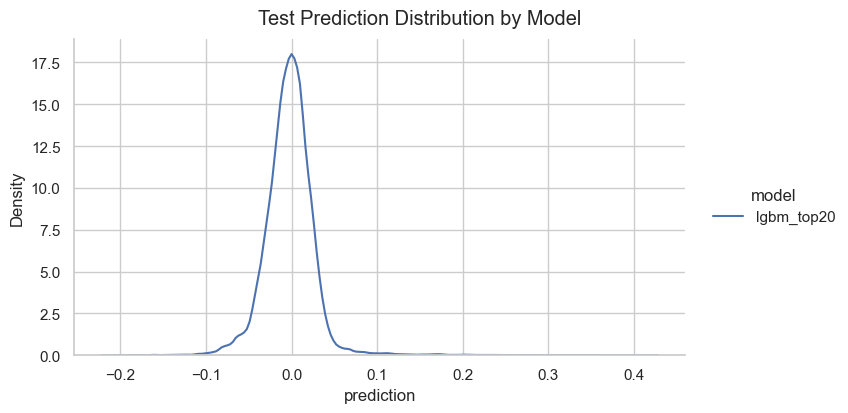

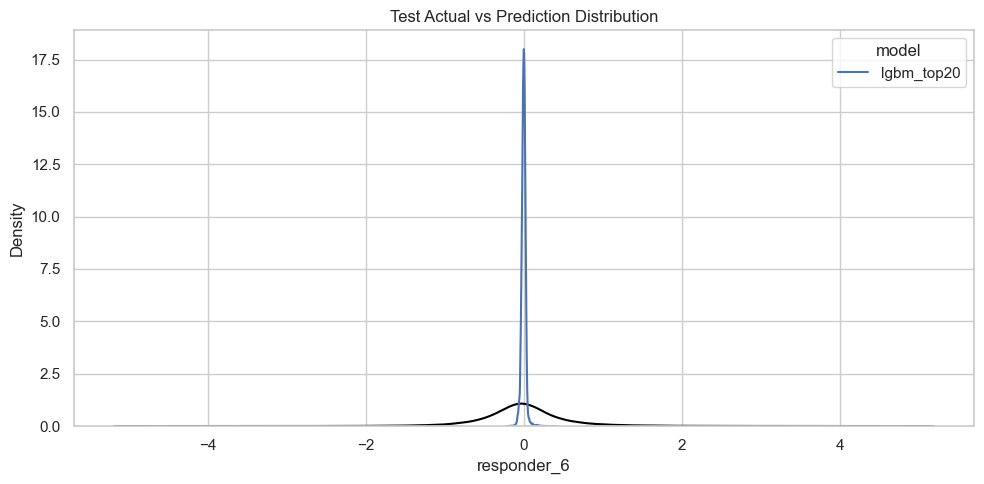

In [11]:
if not pred_df.empty:
    test_plot = pred_df[pred_df["split"] == "test"]
    if len(test_plot) > SAMPLE_ROWS:
        test_plot = test_plot.sample(SAMPLE_ROWS, random_state=RANDOM_STATE)

    g = sns.displot(
        data=test_plot,
        x="prediction",
        hue="model",
        kind="kde",
        height=4,
        aspect=1.8,
        common_norm=False,
    )
    g.fig.suptitle("Test Prediction Distribution by Model", y=1.03)

    plt.figure(figsize=(10, 5))
    sns.kdeplot(data=test_plot, x=TARGET_COL, label="actual", color="black")
    sns.kdeplot(data=test_plot, x="prediction", hue="model", common_norm=False)
    plt.title("Test Actual vs Prediction Distribution")
    plt.tight_layout()

,model,split,date_id,rows,weighted_r2,weighted_rmse,pred_mean,pred_std,target_mean,target_std
145,lgbm_top20,valid,1490,27843,0.007664,0.635302,-0.000977,0.024899,-0.031890,0.649209
146,lgbm_top20,valid,1491,31500,0.000510,0.590447,-0.008227,0.027232,0.015785,0.639576
147,lgbm_top20,valid,1492,32304,0.007645,0.592626,-0.010417,0.030317,0.018031,0.619703
148,lgbm_top20,valid,1493,35072,0.004182,0.546338,-0.006446,0.022792,-0.006711,0.581847
149,lgbm_top20,valid,1494,34200,0.003885,0.482024,-0.007449,0.022033,0.019673,0.506439
150,lgbm_top20,valid,1495,33271,0.002934,0.616034,-0.003138,0.026992,-0.022523,0.657326
151,lgbm_top20,valid,1496,35100,0.005605,0.615977,-0.006367,0.027860,-0.019169,0.636387
152,lgbm_top20,valid,1497,35100,0.003959,0.550659,-0.001171,0.036223,0.006577,0.558055
153,lgbm_top20,valid,1498,35014,0.007412,0.564869,-0.007118,0.030180,0.012515,0.611984
154,lgbm_top20,valid,1499,34898,0.000993,0.778054,-0.014806,0.043588,0.016744,0.808061


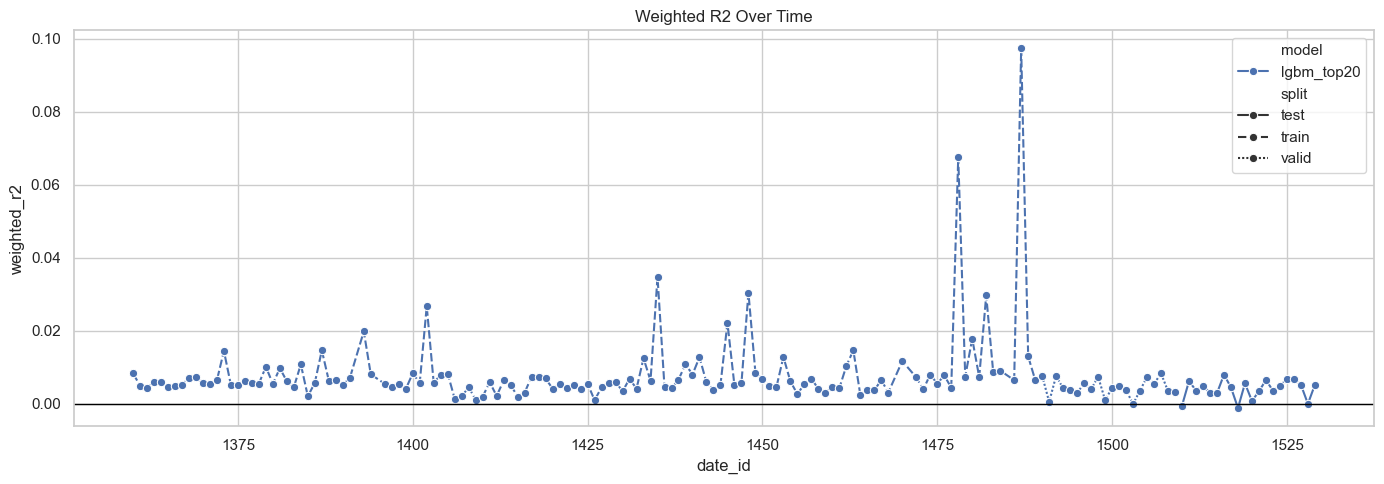

In [12]:
def by_date_metrics(df):
    rows = []
    for (model_name, split_name, date_id), group in df.groupby(["model", "split", DATE_COL]):
        row = {"model": model_name, "split": split_name, "date_id": date_id, "rows": len(group)}
        row.update(score_predictions(group, "prediction"))
        rows.append(row)
    return pd.DataFrame(rows)


date_metrics = by_date_metrics(pred_df)
if not date_metrics.empty:
    plt.figure(figsize=(14, 5))
    sns.lineplot(data=date_metrics, x="date_id", y="weighted_r2", hue="model", style="split", marker="o")
    plt.axhline(0, color="black", linewidth=1)
    plt.title("Weighted R2 Over Time")
    plt.tight_layout()

date_metrics.tail(20)

,model,split,symbol_id,rows,weight_sum,weighted_r2,weighted_rmse,pred_mean,pred_std,target_mean,target_std
19,lgbm_top20,test,19,18000,78053.945312,0.014500,0.492458,0.001903,0.028347,0.018134,0.496119
16,lgbm_top20,test,16,18000,76666.992188,0.010010,0.529955,-0.003174,0.025525,-0.037936,0.526993
38,lgbm_top20,test,38,18000,75879.218750,0.012033,0.423911,-0.011571,0.023171,-0.033988,0.425561
25,lgbm_top20,test,25,17944,63111.898438,-0.001076,0.805657,0.001296,0.031151,-0.020626,0.805416
0,lgbm_top20,test,0,18000,62679.777344,0.005639,0.480171,-0.002620,0.031452,-0.005482,0.481281
11,lgbm_top20,test,11,18000,59062.328125,0.006503,0.415432,-0.000345,0.025635,-0.010807,0.421391
5,lgbm_top20,test,5,17972,58635.738281,0.009903,0.538480,-0.002271,0.026812,-0.030461,0.534050
17,lgbm_top20,test,17,16200,53450.015625,0.004939,0.509224,-0.006414,0.020826,-0.005322,0.515267
7,lgbm_top20,test,7,18000,52393.765625,0.004161,0.461164,-0.005988,0.026242,-0.009554,0.463611
13,lgbm_top20,test,13,18000,52089.609375,0.005974,0.502857,-0.012913,0.022785,-0.022474,0.499671


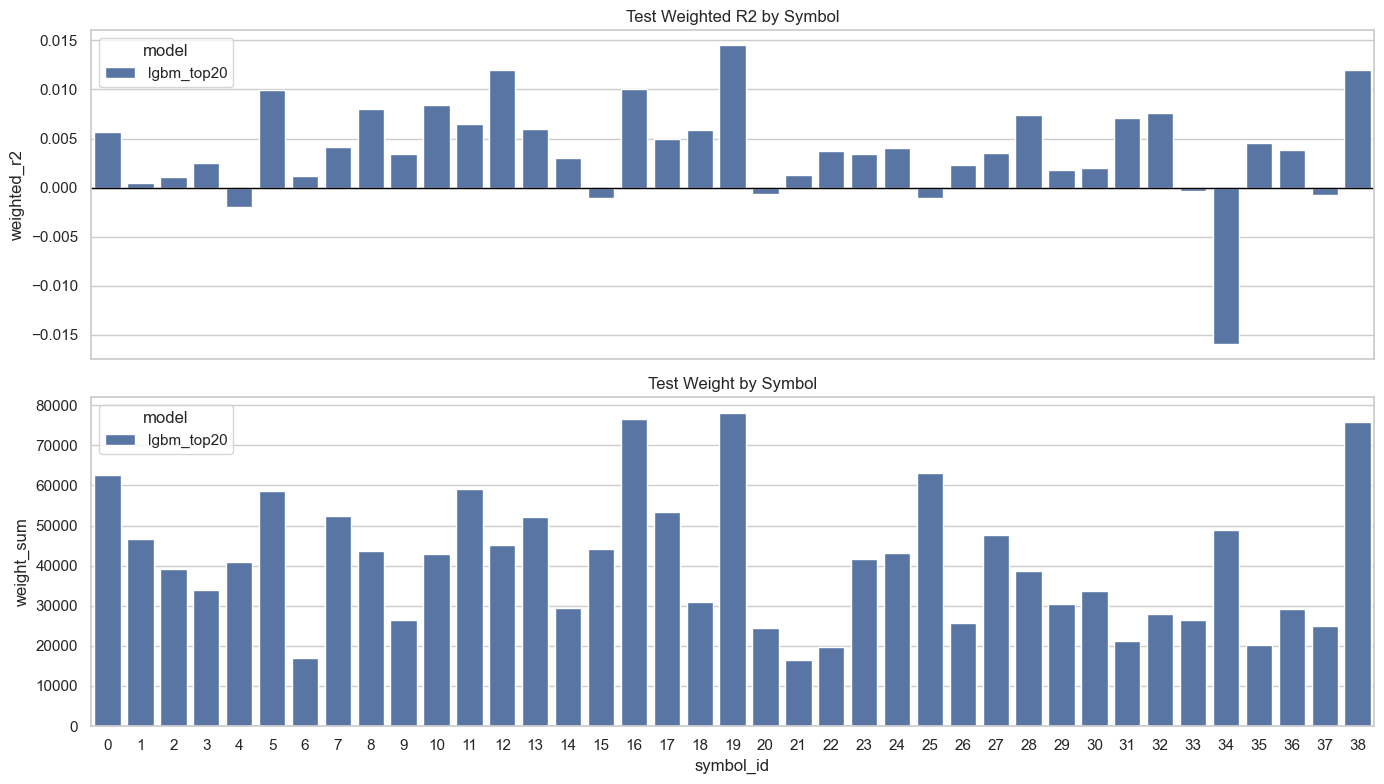

In [13]:
def by_symbol_metrics(df):
    rows = []
    for (model_name, split_name, symbol_id), group in df.groupby(["model", "split", "symbol_id"], observed=True):
        row = {
            "model": model_name,
            "split": split_name,
            "symbol_id": symbol_id,
            "rows": len(group),
            "weight_sum": group[WEIGHT_COL].sum(),
        }
        row.update(score_predictions(group, "prediction"))
        rows.append(row)
    return pd.DataFrame(rows)


symbol_metrics = by_symbol_metrics(pred_df)
test_symbol = symbol_metrics[symbol_metrics["split"] == "test"]
if not test_symbol.empty:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    sns.barplot(data=test_symbol, x="symbol_id", y="weighted_r2", hue="model", ax=axes[0])
    axes[0].axhline(0, color="black", linewidth=1)
    axes[0].set_title("Test Weighted R2 by Symbol")

    sns.barplot(data=test_symbol, x="symbol_id", y="weight_sum", hue="model", ax=axes[1])
    axes[1].set_title("Test Weight by Symbol")
    plt.tight_layout()

symbol_metrics.sort_values(["split", "model", "weight_sum"], ascending=[True, True, False]).head(20)

In [14]:
if not metrics_df.empty:
    summary = metrics_df.pivot_table(index="model", columns="split", values="weighted_r2", aggfunc="first")
    summary = summary.reindex(columns=["train", "valid", "test"])
    display(summary)

phase_score_df


split,train,valid,test
model,,,
lgbm_top20,0.010943,0.004264,0.003757


,model,split,weighted_r2,best_iteration,best_config,report_path
3,rolling_xgb,valid,0.005567,138,shallower,/Users/akshay/Desktop/js_kaggle/logs/train_rol...
1,xgb_top20,valid,0.005500,150,shallower,/Users/akshay/Desktop/js_kaggle/logs/train_top...
2,rolling_lgbm,valid,0.004498,51,more_regularized,/Users/akshay/Desktop/js_kaggle/logs/train_rol...
0,lgbm_top20,valid,0.004264,29,more_regularized,/Users/akshay/Desktop/js_kaggle/logs/train_top...
